# Customer Segmentation with RFM + K-Means Clustering

**Dataset:** UCI Online Retail Dataset (Dec 2010 – Dec 2011, UK-based e-commerce)

**Goal:** Segment customers into meaningful groups based on their purchasing behavior, using **RFM analysis** (Recency, Frequency, Monetary value) and **K-Means clustering**, so that a business could target each segment differently (e.g. reward loyal customers, win back lapsed ones).

**Project workflow:**
1. Load & clean the raw transaction data
2. Exploratory Data Analysis (EDA)
3. Feature engineering — build the RFM table
4. Data preprocessing — transform & scale features for clustering
5. Check whether the data is actually suitable for clustering
6. Choose the number of clusters (K)
7. Train the K-Means model
8. Evaluate the clustering
9. Interpret & visualize the segments
10. (Optional) Save the model for reuse


## 1. Setup — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.width', 120)


## 2. Load the Raw Data

Make sure `Online Retail.xlsx` is in the same folder as this notebook (or update the path below).

In [2]:
df = pd.read_excel('Online Retail.xlsx')

print("Shape:", df.shape)
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### What's in this data?

| Column | Meaning |
|---|---|
| `InvoiceNo` | Order/invoice number. Starts with 'C' if it's a cancellation |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units purchased (negative = returned/cancelled) |
| `InvoiceDate` | Date & time of the transaction |
| `UnitPrice` | Price per unit |
| `CustomerID` | Unique customer identifier (many rows are missing this!) |
| `Country` | Customer's country |

Let's check data quality before doing anything else.

In [3]:
print("--- Missing values ---")
print(df.isna().sum())
print()
print("--- % missing ---")
print((df.isna().sum() / len(df) * 100).round(2))


--- Missing values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- % missing ---
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


## 3. Data Cleaning

Several issues need fixing before this data is usable for RFM analysis:
- ~25% of rows have no `CustomerID` — can't attribute those purchases to anyone
- Exact duplicate rows (data export errors)
- Cancelled orders (`InvoiceNo` starting with `'C'`) — negative quantities, not real purchases
- Rows with non-positive price or quantity (data errors, adjustments)
- Non-product stock codes like `POST` (postage), `M` (manual entry), `D` (discount) — these are fees, not genuine product purchases

Each step below explains **why**, not just what.

In [4]:
# Drop rows with missing CustomerID -> without a customer ID we can't attribute
# the purchase to anyone, so these rows are useless for RFM/segmentation.
df = df.dropna(subset=['CustomerID'])
print("After dropping missing CustomerID:", df.shape)


After dropping missing CustomerID: (406829, 8)


In [5]:
# Drop fully duplicated rows -> exact duplicates are almost always
# data entry/export errors, not genuinely repeated transactions.
df = df.drop_duplicates()
print("After dropping duplicates:", df.shape)


After dropping duplicates: (401604, 8)


In [6]:
# Remove cancelled orders (InvoiceNo starting with 'C') -> these represent
# returns/cancellations (negative quantity), which we don't want counted
# as "purchases" for Frequency/Monetary calculations.
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("After removing cancellations:", df.shape)


After removing cancellations: (392732, 8)


In [7]:
# Remove any remaining non-positive Quantity or UnitPrice rows -> these are
# leftover manual adjustments/errors (e.g. "bad debt" write-offs), not
# genuine purchases, and would corrupt the Monetary calculation.
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print("After removing non-positive Quantity/UnitPrice:", df.shape)


After removing non-positive Quantity/UnitPrice: (392692, 8)


In [8]:
# Drop non-product StockCodes (POST, DOT, M, PADS, etc.) -> these are
# postage charges, manual/bank entries, or misc fees, not real product
# purchases. They'd inflate Monetary value without reflecting genuine
# buying behavior, which is what we want RFM to capture.
non_product_codes = ['POST', 'DOT', 'M', 'D', 'S', 'AMAZONFEE', 'CRUK', 'PADS', 'm', 'B']
df = df[~df['StockCode'].isin(non_product_codes)]
print("After removing non-product stock codes:", df.shape)


After removing non-product stock codes: (391295, 8)


In [9]:
# Create TotalPrice = Quantity * UnitPrice -> this is the actual money
# value of each line item, which we need to compute Monetary value per customer.
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Make CustomerID a clean integer, not a float like 17850.0 -> it's an ID,
# not a real number, so keeping it as float invites bugs later.
df['CustomerID'] = df['CustomerID'].astype(int)

print("Final cleaned shape:", df.shape)
df.head()


Final cleaned shape: (391295, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [10]:
# Save the cleaned dataset so we don't have to re-clean every time
df.to_csv('online_retail_cleaned.csv', index=False)


## 4. Exploratory Data Analysis (EDA)

Before building features, let's get a feel for the business: how revenue trends over time, which markets matter, and how spending is distributed across customers.

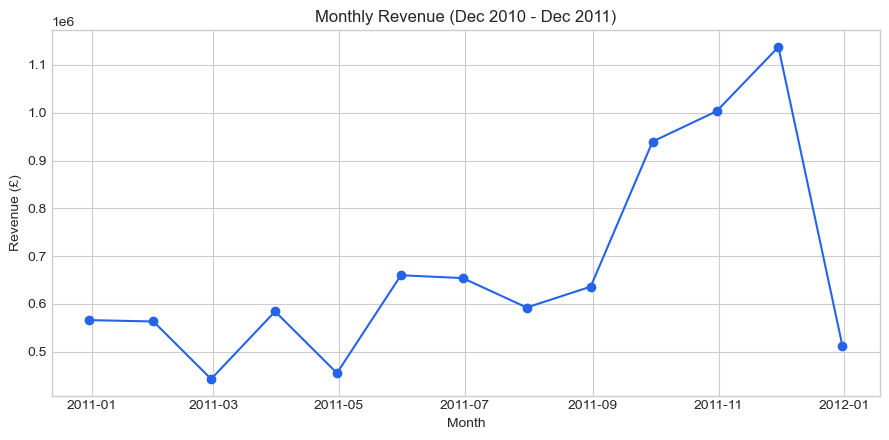

In [11]:
df = pd.read_csv('online_retail_cleaned.csv', parse_dates=['InvoiceDate'])

# Monthly revenue trend -> shows overall business trajectory and seasonality
monthly_rev = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly_rev.index, monthly_rev.values, marker='o', color='#2563eb')
ax.set_title('Monthly Revenue (Dec 2010 - Dec 2011)')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('Month')
fig.tight_layout()
plt.show()


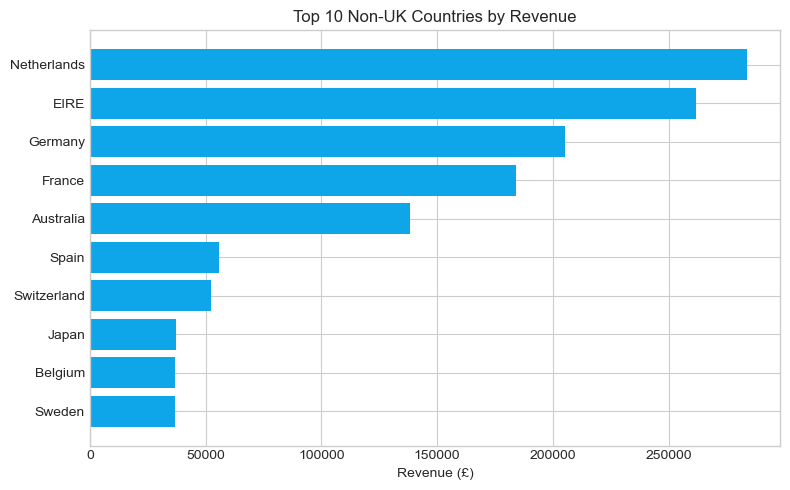

In [12]:
# Top 10 non-UK countries by revenue -> UK dominates (~83% of revenue),
# so excluding it lets us see the next tier of markets
country_rev = (df[df['Country'] != 'United Kingdom']
               .groupby('Country')['TotalPrice'].sum()
               .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(country_rev.index[::-1], country_rev.values[::-1], color='#0ea5e9')
ax.set_title('Top 10 Non-UK Countries by Revenue')
ax.set_xlabel('Revenue (£)')
fig.tight_layout()
plt.show()


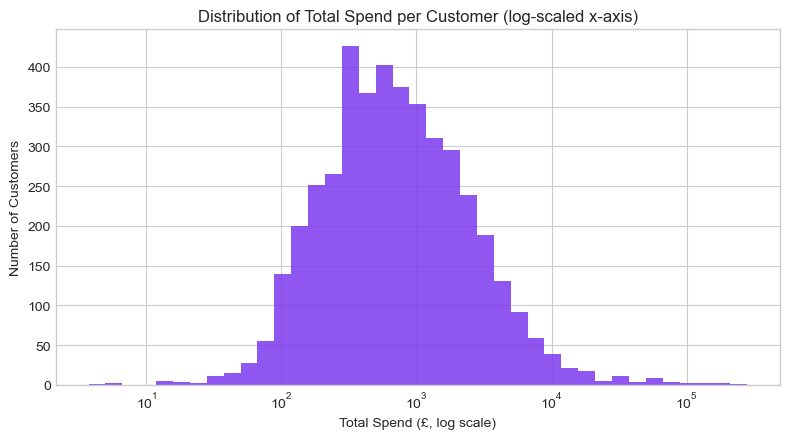

Revenue-per-customer skewness: 19.55


In [13]:
# Distribution of customer spend (log-scaled bins) -> reveals the data is
# heavily right-skewed, which tells us we'll need to log-transform before
# clustering with K-Means
rev_per_cust = df.groupby('CustomerID')['TotalPrice'].sum()
bins = np.logspace(np.log10(rev_per_cust.min()), np.log10(rev_per_cust.max()), 40)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(rev_per_cust, bins=bins, color='#7c3aed', alpha=0.85)
ax.set_xscale('log')
ax.set_title('Distribution of Total Spend per Customer (log-scaled x-axis)')
ax.set_xlabel('Total Spend (£, log scale)')
ax.set_ylabel('Number of Customers')
fig.tight_layout()
plt.show()

print("Revenue-per-customer skewness:", rev_per_cust.skew().round(2))


## 5. Feature Engineering — Building the RFM Table

This is the core step for the whole project. We collapse the transaction-level data (multiple rows per customer) into **one row per customer** with three behavioral features:

- **Recency** — days since their last purchase (lower = more engaged)
- **Frequency** — number of distinct orders they've placed
- **Monetary** — total amount they've spent

In [14]:
# The "snapshot date" is our reference point for "today" — one day after
# the last transaction in the dataset, since Recency needs to be measured
# relative to some fixed point in time.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),   # distinct invoices, not line items
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.describe()


Snapshot date: 2011-12-10 12:50:00
(4335, 4)


,CustomerID,Recency,Frequency,Monetary
count,4335.000000,4335.000000,4335.000000,4335.000000
mean,15299.372549,92.708651,4.248212,2017.088499
std,1721.813812,100.206617,7.646024,8919.392095
min,12346.000000,1.000000,1.000000,3.750000
25%,13812.500000,18.000000,1.000000,304.250000
50%,15298.000000,51.000000,2.000000,663.610000
75%,16778.500000,143.000000,5.000000,1631.475000
max,18287.000000,374.000000,206.000000,279138.020000


In [15]:
rfm.to_csv('rfm_table.csv', index=False)
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40


## 6. Data Preprocessing — Preparing RFM for K-Means

K-Means uses **Euclidean distance**, which makes it sensitive to two things:
1. **Skewed distributions** — a few extreme spenders would distort distances
2. **Feature scale** — Monetary (in the thousands) would dominate over Frequency (single digits) if left unscaled

So we log-transform each feature to reduce skew, then standardize so all three features contribute equally.

In [16]:
print("Skewness before log transform:")
print("  Recency:  ", rfm['Recency'].skew().round(2))
print("  Frequency:", rfm['Frequency'].skew().round(2))
print("  Monetary: ", rfm['Monetary'].skew().round(2))


Skewness before log transform:
  Recency:   1.24
  Frequency: 11.97
  Monetary:  19.55


In [17]:
# log1p (log(1+x)) is used instead of plain log to safely handle any zero values
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

print("Skewness after log transform:")
print("  Recency:  ", rfm['Recency_log'].skew().round(2))
print("  Frequency:", rfm['Frequency_log'].skew().round(2))
print("  Monetary: ", rfm['Monetary_log'].skew().round(2))


Skewness after log transform:
  Recency:   -0.38
  Frequency: 1.21
  Monetary:  0.4


In [18]:
# Standardize (mean=0, std=1) so no single feature dominates the distance
# calculation that K-Means relies on
features = ['Recency_log', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

# Keep CustomerID attached (to map clusters back to customers later) but
# OUT of the feature matrix itself, since it's an identifier, not a behavior
rfm_final = pd.concat([rfm[['CustomerID']], rfm_scaled], axis=1)

rfm.to_csv('rfm_table.csv', index=False)
rfm_final.to_csv('rfm_scaled_for_clustering.csv', index=False)

rfm_final.head()


,CustomerID,Recency_scaled,Frequency_scaled,Monetary_scaled
0,12346,1.460165,-0.951420,3.726618
1,12347,-2.037990,1.081712,1.428561
2,12348,0.372077,0.392407,0.554153
3,12349,-0.623381,-0.951420,0.565323
4,12350,1.422757,-0.951420,-0.706655


## 7. Is This Data Actually Suitable for Clustering?

Before training anything, it's worth checking whether the data has genuine group structure, or whether it's essentially uniform/random (in which case any "clusters" found would be somewhat arbitrary).

We use the **Hopkins statistic**: it compares real data-point distances to their nearest neighbors against the same measurement on randomly-generated points spanning the same space.
- ~0.5 → no real structure (random)
- Closer to 1 → strong genuine cluster tendency

In [19]:
X = rfm_final[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']].values

def hopkins_statistic(X, sample_ratio=0.1, seed=42):
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    m = int(sample_ratio * n)
    d = X.shape[1]

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # Distance from real sampled points to their nearest REAL neighbor
    idx = rng.choice(n, m, replace=False)
    real_sample = X[idx]
    u_dist, _ = nbrs.kneighbors(real_sample, n_neighbors=2)
    u_dist = u_dist[:, 1]

    # Distance from random uniform points to their nearest REAL neighbor
    mins, maxs = X.min(axis=0), X.max(axis=0)
    random_points = rng.uniform(mins, maxs, (m, d))
    w_dist, _ = nbrs.kneighbors(random_points, n_neighbors=1)
    w_dist = w_dist[:, 0]

    return np.sum(w_dist) / (np.sum(u_dist) + np.sum(w_dist))

H = hopkins_statistic(X)
print(f"Hopkins statistic: {H:.3f}  (0.5 = random, closer to 1 = strong cluster tendency)")


Hopkins statistic: 0.949  (0.5 = random, closer to 1 = strong cluster tendency)


Explained variance captured by 2 components: 93.8%


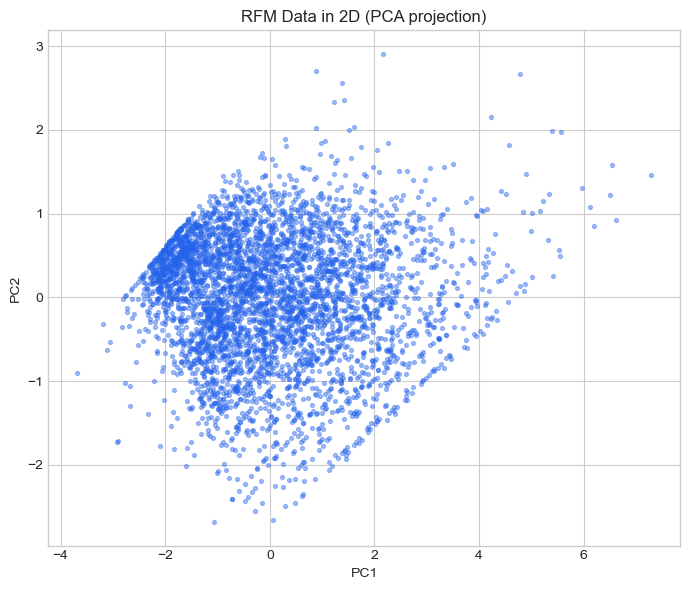

In [20]:
# Visualize in 2D via PCA just to eyeball whether there's visible structure
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"Explained variance captured by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.4, color='#2563eb')
ax.set_title('RFM Data in 2D (PCA projection)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.tight_layout()
plt.show()


**Note:** the data will likely look like one continuous cloud rather than obviously separate blobs — that's normal for behavioral data like this. Customers exist on a spectrum, not in neatly pre-separated islands. K-Means will still draw sensible dividing lines through that spectrum; a high Hopkins statistic confirms the structure is real, not that it'll look like visibly separate clumps.

## 8. Choosing the Number of Clusters (K)

K-Means needs K decided in advance. We use two standard techniques together:

- **Elbow method**: plot inertia (within-cluster sum of squares) vs. K, look for where the curve stops dropping steeply
- **Silhouette score**: measures how well-separated clusters are (range -1 to 1, higher is better)

In [21]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.4f}")


K=2: inertia=6479.8, silhouette=0.4329
K=3: inertia=4864.8, silhouette=0.3375
K=4: inertia=3934.9, silhouette=0.3367
K=5: inertia=3291.8, silhouette=0.3163
K=6: inertia=2851.9, silhouette=0.3134
K=7: inertia=2549.0, silhouette=0.3091
K=8: inertia=2337.6, silhouette=0.2973
K=9: inertia=2157.4, silhouette=0.2806
K=10: inertia=2000.2, silhouette=0.2775


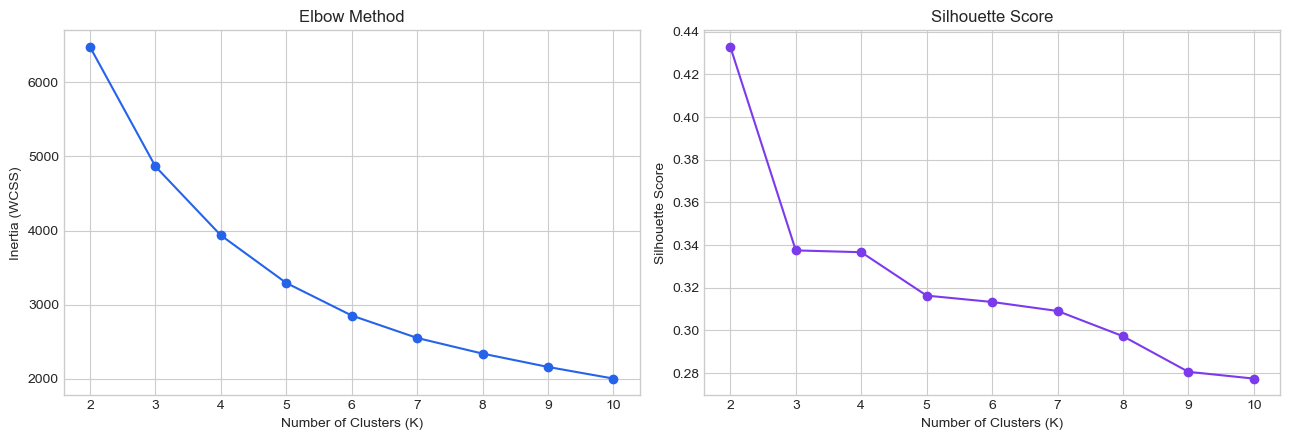

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker='o', color='#2563eb')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#7c3aed')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

fig.tight_layout()
plt.show()


**Choosing K=4:** K=2 technically scores highest on silhouette, but it's too coarse to be useful for marketing (basically just "spenders vs. non-spenders"). The elbow bends around K=3–4, and silhouette is nearly identical between K=3 and K=4. K=4 is the practical trade-off — a reasonable mathematical fit while still giving enough distinct, actionable segments to work with.

Feel free to try K=3 or K=5 yourself and compare — this is a judgment call, not a fixed rule.

## 9. Train the Final K-Means Model

In [23]:
# n_init=10 runs K-Means 10 times with different random centroid starting
# points and keeps the best result, since K-Means can converge to a bad
# local optimum depending on where centroids start
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X)

rfm['Cluster'].value_counts().sort_index()


Cluster
0     850
1    1606
2    1175
3     704
Name: count, dtype: int64

## 10. Evaluate the Clustering

Unlike supervised learning, there's no ground-truth label to check against — so there's no accuracy/precision/recall. Instead we look at how well-separated and internally consistent the clusters are. These numbers are mainly useful for *comparing* different K values, not as a pass/fail threshold.

In [24]:
sil = silhouette_score(X, rfm['Cluster'])
db = davies_bouldin_score(X, rfm['Cluster'])
ch = calinski_harabasz_score(X, rfm['Cluster'])

print(f"Silhouette Score:        {sil:.4f}   (higher is better, range -1 to 1)")
print(f"Davies-Bouldin Index:    {db:.4f}   (lower is better)")
print(f"Calinski-Harabasz Index: {ch:.1f}   (higher is better)")


Silhouette Score:        0.3367   (higher is better, range -1 to 1)
Davies-Bouldin Index:    1.0143   (lower is better)
Calinski-Harabasz Index: 3327.7   (higher is better)


## 11. Interpret the Segments

We profile each cluster using the **original, non-scaled** RFM values — the log/scaled versions are what the model needed, but real numbers are what actually make sense to a human (or a marketing team) reading the segments.

In [25]:
cluster_profile = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count')
).round(1)

cluster_profile['% of Customers'] = (cluster_profile['CustomerCount'] / cluster_profile['CustomerCount'].sum() * 100).round(1)
cluster_profile['% of Revenue'] = (rfm.groupby('Cluster')['Monetary'].sum() / rfm['Monetary'].sum() * 100).round(1)

cluster_profile.sort_values('Monetary', ascending=False)


,Recency,Frequency,Monetary,CustomerCount,% of Customers,% of Revenue
Cluster,,,,,,
3,11.8,13.7,8004.2,704,16.2,64.4
2,68.9,4.1,1791.9,1175,27.1,24.1
0,19.1,2.1,525.2,850,19.6,5.1
1,184.6,1.3,347.0,1606,37.0,6.4


### Naming the segments

Fill this in based on the profile table above (numbers will shift slightly depending on your exact K/random_state, so re-read your own table before naming):

| Cluster | Typical Profile | Suggested Name | Suggested Action |
|---|---|---|---|
| Low recency, high frequency, high monetary | Bought recently, often, big spender | **VIP / Champions** | Loyalty rewards, early access to new products |
| Moderate recency, moderate frequency/monetary | Fairly engaged, steady | **Loyal / Regulars** | Upsell, cross-sell campaigns |
| Low recency, low frequency | Bought recently but only once/rarely so far | **New / Promising** | Onboarding campaigns, encourage 2nd purchase |
| High recency, low frequency, low monetary | Haven't purchased in a long time | **At Risk / Lapsed** | Win-back discounts, re-engagement email |


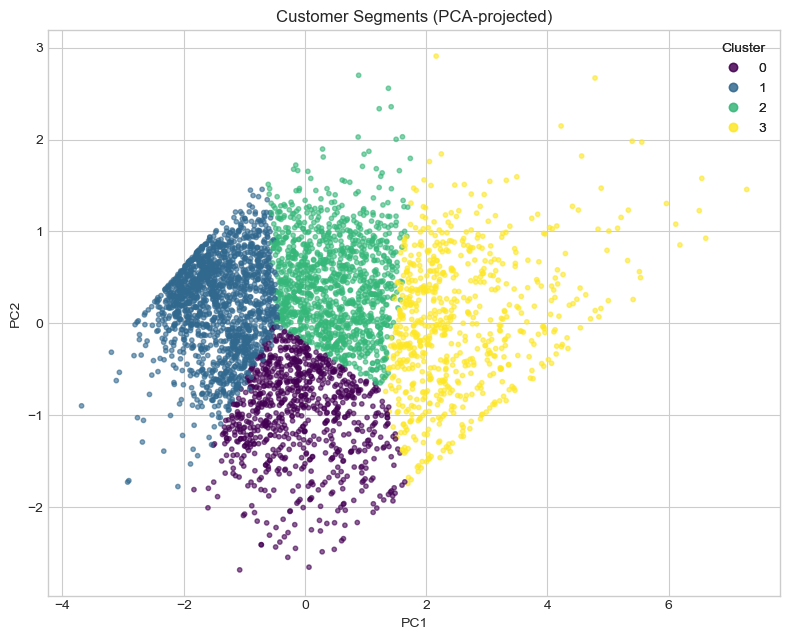

In [26]:
# Visualize clusters in 2D (PCA) colored by segment, for a visual gut-check
# that the assigned clusters roughly align with the geometry we saw earlier
fig, ax = plt.subplots(figsize=(8, 6.5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm['Cluster'], cmap='viridis', s=10, alpha=0.6)
ax.set_title('Customer Segments (PCA-projected)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend)
fig.tight_layout()
plt.show()


In [27]:
rfm.to_csv('rfm_with_clusters.csv', index=False)
print("Saved rfm_with_clusters.csv — one row per customer with their assigned segment")


Saved rfm_with_clusters.csv — one row per customer with their assigned segment


## 12. Production Pipeline — Reusable Scoring Class

So far every step has been manual, run cell-by-cell. To actually deploy this, we need something that can be called on **new, unseen data** with one line of code, and gives **consistent segment names** even if the model gets retrained later.

We wrap the RFM calculation + scaler + K-Means model + segment naming into a single class:
- `fit(df)` — trains everything from scratch on raw transaction data (what we did manually above)
- `predict(df)` — scores NEW customers using the already-fitted scaler/model (no re-fitting!)
- `save()` / `load()` — persists the whole pipeline to disk

**Why segment naming needs to be automatic:** cluster *numbers* (0, 1, 2, 3) are arbitrary and can shuffle every time you retrain. So instead of hardcoding "Cluster 3 = VIP", we rank clusters by their actual behavior (low recency + high frequency + high monetary = best) and assign names based on that ranking — so "VIP" always means the best-behaving cluster, regardless of what number K-Means happened to assign it.

In [28]:
import joblib

class CustomerSegmentationPipeline:
    """
    End-to-end customer segmentation pipeline.

    Wraps RFM feature engineering + scaling + K-Means + segment naming into
    one object, so new customer data can be scored consistently with a
    single method call instead of manually repeating every notebook step.
    """

    def __init__(self, n_clusters=4, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        self.feature_cols = ['Recency_log', 'Frequency_log', 'Monetary_log']
        self.segment_names = {}   # filled in during fit()
        self.snapshot_date_ = None  # the fixed "today" reference, set during fit()

    def _compute_rfm(self, df, snapshot_date):
        """
        Turn raw transaction-level rows into one row per customer (RFM).
        snapshot_date is REQUIRED (not inferred from df here) so that
        Recency is always measured against the same fixed reference point,
        whether we're fitting or scoring new data. If each call inferred
        "today" from its own batch's most recent date, two batches covering
        different time windows would produce Recency values that aren't
        comparable to each other -- which would look like fake "drift"
        that's really just an artifact of how the batches were split.
        """
        rfm = df.groupby('CustomerID').agg(
            Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
            Frequency=('InvoiceNo', 'nunique'),
            Monetary=('TotalPrice', 'sum')
        ).reset_index()
        rfm['Recency_log'] = np.log1p(rfm['Recency'])
        rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
        rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
        return rfm

    def _assign_segment_names(self, rfm_with_clusters):
        """
        Give each cluster a STABLE, human-readable name based on its
        behavior, instead of an arbitrary cluster number. Ranks clusters
        by a composite score: low recency + high frequency + high monetary
        = best (most engaged) customers.
        """
        profile = rfm_with_clusters.groupby('Cluster').agg(
            Recency=('Recency', 'mean'),
            Frequency=('Frequency', 'mean'),
            Monetary=('Monetary', 'mean')
        )
        recency_rank = profile['Recency'].rank(ascending=True)    # lower recency = better = rank 1
        freq_rank = profile['Frequency'].rank(ascending=False)    # higher frequency = better = rank 1
        monetary_rank = profile['Monetary'].rank(ascending=False) # higher monetary = better = rank 1
        composite_score = recency_rank + freq_rank + monetary_rank

        ordered_clusters = composite_score.sort_values().index.tolist()  # best -> worst

        n = len(ordered_clusters)
        if n == 4:
            names = ['VIP / Champions', 'Loyal / Regulars', 'New / Promising', 'At Risk / Lapsed']
        else:
            names = [f'Segment {i+1}' for i in range(n)]  # fallback if K != 4
        return dict(zip(ordered_clusters, names))

    def fit(self, df, snapshot_date=None):
        """
        Fit the full pipeline on raw transaction-level data.
        If snapshot_date isn't given, defaults to one day after the last
        transaction in df (i.e. "today" = right after this data ends).
        """
        if snapshot_date is None:
            snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
        self.snapshot_date_ = snapshot_date

        rfm = self._compute_rfm(df, snapshot_date)
        X = self.scaler.fit_transform(rfm[self.feature_cols])
        rfm['Cluster'] = self.kmeans.fit_predict(X)
        self.segment_names = self._assign_segment_names(rfm)
        rfm['Segment'] = rfm['Cluster'].map(self.segment_names)
        return rfm

    def predict(self, df, snapshot_date=None):
        """
        Score NEW raw transaction data using the already-fitted pipeline.
        By default reuses the SAME snapshot_date the pipeline was fit with,
        so Recency stays comparable to training. Pass an explicit later
        snapshot_date (e.g. pd.Timestamp.now()) when scoring in production
        well after training happened.
        """
        if snapshot_date is None:
            snapshot_date = self.snapshot_date_

        rfm = self._compute_rfm(df, snapshot_date)
        X = self.scaler.transform(rfm[self.feature_cols])   # transform, NOT fit_transform
        rfm['Cluster'] = self.kmeans.predict(X)
        rfm['Segment'] = rfm['Cluster'].map(self.segment_names)
        return rfm

    def save(self, path='segmentation_pipeline.pkl'):
        joblib.dump(self, path)

    @staticmethod
    def load(path='segmentation_pipeline.pkl'):
        return joblib.load(path)


In [29]:
# Fit the pipeline on the full cleaned dataset (same result as our manual
# steps above, but now packaged as one reusable object)
pipeline = CustomerSegmentationPipeline(n_clusters=4, random_state=42)
rfm_labeled = pipeline.fit(df)

print(pipeline.segment_names)
rfm_labeled[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head()


{3: 'VIP / Champions', 2: 'Loyal / Regulars', 0: 'New / Promising', 1: 'At Risk / Lapsed'}


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,2,Loyal / Regulars
1,12347,2,7,4310.00,3,VIP / Champions
2,12348,75,4,1437.24,2,Loyal / Regulars
3,12349,19,1,1457.55,0,New / Promising
4,12350,310,1,294.40,1,At Risk / Lapsed


In [30]:
# Example: scoring "new" customers with the already-fitted pipeline.
# In production this would be a fresh batch of recent transactions;
# here we just reuse a slice of df to demonstrate predict() works end-to-end.
sample_new_data = df.sample(500, random_state=1)
scored = pipeline.predict(sample_new_data)
scored['Segment'].value_counts()


Segment
At Risk / Lapsed    362
New / Promising      44
Name: count, dtype: int64

## 13. Temporal Validation

Every evaluation so far has tested the model on the **same data it was trained on** — that tells us nothing about whether the segments hold up on data the model hasn't seen. A model that only works on its own training data isn't something you'd trust in production.

Here we simulate a real deployment scenario:
- **Train** the pipeline using only the first ~75% of the timeline
- **Test** it by scoring customers from the final ~25% of the timeline (later data it never saw during fitting)
- Compare silhouette scores between the two — if the test score holds up reasonably close to the train score, the segments generalize. If it collapses, the model was overfit to a specific time window.

In [31]:
cutoff_date = df['InvoiceDate'].quantile(0.75)
train_df = df[df['InvoiceDate'] <= cutoff_date]
test_df = df[df['InvoiceDate'] > cutoff_date]

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train transactions: {len(train_df):,}  |  Test transactions: {len(test_df):,}")

# Use ONE shared snapshot_date (based on the full dataset's last date) for
# both fitting and scoring, so Recency is measured on the same footing for
# train and test customers -- otherwise the shorter test window would make
# Recency look artificially different for reasons that have nothing to do
# with real behavioral drift.
global_snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

temporal_pipeline = CustomerSegmentationPipeline(n_clusters=4, random_state=42)
train_rfm = temporal_pipeline.fit(train_df, snapshot_date=global_snapshot)
test_rfm = temporal_pipeline.predict(test_df, snapshot_date=global_snapshot)

X_train_eval = temporal_pipeline.scaler.transform(train_rfm[temporal_pipeline.feature_cols])
X_test_eval = temporal_pipeline.scaler.transform(test_rfm[temporal_pipeline.feature_cols])

train_sil = silhouette_score(X_train_eval, train_rfm['Cluster'])
test_sil = silhouette_score(X_test_eval, test_rfm['Cluster'])

print(f"\nTrain-period silhouette score: {train_sil:.4f}")
print(f"Test-period silhouette score:  {test_sil:.4f}  (scored using the train-fitted model)")


Cutoff date: 2011-10-20
Train transactions: 293,508  |  Test transactions: 97,787

Train-period silhouette score: 0.3651
Test-period silhouette score:  0.1389  (scored using the train-fitted model)


**How to read this:** a test score reasonably close to the train score means the segments generalize to customers the model never saw — the RFM patterns that define "VIP" or "At Risk" aren't specific to one time window. A large drop would be a warning sign that the model is overfit and needs revisiting.

## 14. Drift Monitoring — Knowing When to Retrain

In production, customer behavior changes over time (seasonality, promotions, changing market conditions). A model trained once and never revisited will slowly become less accurate. **Drift monitoring** is how you detect that automatically, instead of guessing.

We use the **Population Stability Index (PSI)** — a standard technique for measuring how much a feature's distribution has shifted between two time periods (commonly used in credit scoring / marketing analytics).

**Rule of thumb for reading PSI:**
| PSI value | Meaning |
|---|---|
| < 0.10 | No significant shift — model is still healthy |
| 0.10 – 0.25 | Moderate shift — worth monitoring |
| > 0.25 | Significant shift — retrain the model |

In [32]:
def population_stability_index(expected, actual, buckets=10):
    """
    Measures how much a distribution ('actual') has shifted compared to a
    baseline ('expected'), by binning both into the same percentile buckets
    and comparing bucket proportions.
    """
    breakpoints = np.linspace(0, 100, buckets + 1)
    bucket_edges = np.percentile(expected, breakpoints)
    bucket_edges[0] -= 1e-6   # widen edges slightly so min/max values aren't excluded
    bucket_edges[-1] += 1e-6

    expected_pct = np.histogram(expected, bins=bucket_edges)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=bucket_edges)[0] / len(actual)

    # Avoid divide-by-zero / log(0) for empty buckets
    expected_pct = np.clip(expected_pct, 1e-4, None)
    actual_pct = np.clip(actual_pct, 1e-4, None)

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi


print("Drift check: comparing train-period RFM distributions vs. test-period\n")
for col in ['Recency', 'Frequency', 'Monetary']:
    psi = population_stability_index(train_rfm[col], test_rfm[col])
    if psi > 0.25:
        flag = "RETRAIN RECOMMENDED"
    elif psi > 0.10:
        flag = "Monitor"
    else:
        flag = "Stable"
    print(f"  {col:<10} PSI = {psi:.3f}  ->  {flag}")


Drift check: comparing train-period RFM distributions vs. test-period

  Recency    PSI = 6.388  ->  RETRAIN RECOMMENDED
  Frequency  PSI = 0.357  ->  RETRAIN RECOMMENDED
  Monetary   PSI = 0.197  ->  Monitor


**A methodology caveat worth understanding:** the Recency PSI here is large partly by construction, not purely from real behavioral drift. The test set only contains transactions after the cutoff date, so every test-period customer's Recency is necessarily small (they can only look recent relative to a window that only spans that recent period). Frequency and Monetary are lower in the test set for a similar reason -- customers had less total time to accumulate orders within a shorter window.

This is a known limitation of splitting transaction-level data by date and then computing RFM separately per split: the window length itself shapes the RFM distribution, independent of whether customer behavior actually changed.

What this means in practice: a production drift-monitoring setup should compare RFM computed with the same lookback length each time (e.g. always trailing 12 months), or compare the same customers' RFM at two points in time, rather than comparing RFM computed from windows of different lengths. The PSI mechanism itself is correct and reusable -- just be careful the two distributions you're comparing are actually apples-to-apples before trusting a retrain flag.

**In a real deployment**, this PSI check would run automatically every time a new batch of customer data comes in (e.g. weekly/monthly), comparing it against the distribution the model was originally trained on. If PSI crosses the retrain threshold, that triggers an alert (or an automatic retraining job) instead of silently letting the model degrade.

## 15. Save the Production Pipeline

Save the full pipeline object (scaler + model + segment names all together) so it can be loaded and used to score new customers without re-running any of the notebook.

In [33]:
# Save the FULL pipeline fit on all available data (not the temporal train/test split)
pipeline.save('segmentation_pipeline.pkl')
print("Saved segmentation_pipeline.pkl")

# --- How you'd use it later, e.g. in a separate scoring script ---
# loaded_pipeline = CustomerSegmentationPipeline.load('segmentation_pipeline.pkl')
# new_transactions = pd.read_excel('latest_orders.xlsx')
# results = loaded_pipeline.predict(new_transactions)
# results[['CustomerID', 'Segment']].to_csv('latest_segment_assignments.csv', index=False)


Saved segmentation_pipeline.pkl


In [34]:
rfm_labeled.to_csv('rfm_with_clusters.csv', index=False)
print("Saved rfm_with_clusters.csv")


Saved rfm_with_clusters.csv


## 16. Conclusion & Next Steps

**What we did:** cleaned raw transaction data → engineered RFM features → checked the data was suitable for clustering → chose K via elbow/silhouette → trained K-Means → evaluated and interpreted 4 customer segments → **packaged everything into a reusable scoring pipeline → validated it on unseen future data → added drift monitoring to know when it needs retraining.**

**What makes this production-ready now:**
- ✅ A single `CustomerSegmentationPipeline` class that can score new customers with one method call
- ✅ Segment names that stay consistent even if the model is retrained (ranked by behavior, not arbitrary cluster number)
- ✅ Validated on a held-out future time period, not just training data
- ✅ Automated drift detection (PSI) to flag when retraining is actually needed

**Possible next steps to extend this further:**
- Wrap `predict()` in a small script/API endpoint that reads a CSV and writes segment assignments
- Automate the retrain trigger: if PSI > 0.25, automatically refit and redeploy the pipeline
- Try alternative algorithms (DBSCAN, hierarchical clustering) and compare against this K-Means baseline
- Add features beyond RFM (average order value, product category diversity)
